In [1]:
import matplotlib.pyplot as plt
import numpy as np

from firm3d.plotting.plotting_helpers import plot_trajectory_poloidal

In [2]:
FontSize = 18
label_kw = {"fontfamily": "Times New Roman", "fontsize": FontSize}
tick_labelsize = FontSize - 1

plt.rcParams.update(
    {
        "font.family": "Times New Roman",
        "mathtext.fontset": "custom",
        "mathtext.rm": "Times New Roman",
        "mathtext.it": "Times New Roman:italic",
        "mathtext.bf": "Times New Roman:bold",
    }
)

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Nimbus Roman No9 L", "Liberation Serif", "DejaVu Serif"],
})

# Default axes box in figure coordinates (0–1); tune once, reuse everywhere
AXES_MARGINS = dict(left=0.14, right=0.90, bottom=0.14, top=0.98) # percentages of the figure height/width

plt.rcParams.update(
    {
        "figure.subplot.left": AXES_MARGINS["left"],
        "figure.subplot.right": AXES_MARGINS["right"],
        "figure.subplot.bottom": AXES_MARGINS["bottom"],
        "figure.subplot.top": AXES_MARGINS["top"],
        # optional: spacing for multi-panel figures
        "figure.subplot.wspace": 0.25,
        "figure.subplot.hspace": 0.25,
    }
)


# apply to figures to apply even if using tight_layout
# AXES_MARGINS = dict(left=0.14, right=0.98, bottom=0.14, top=0.82)
def apply_standard_axes(fig):
    fig.subplots_adjust(**AXES_MARGINS)

promptloss_thres = 2
nParticles = int(5e5)


QA

In [3]:
nParticles = int(5e5)

trapped_bool = []  # True if particle mirrors at least once
barely_trapped_frac = []  # Fraction barely trapped (dchis > 2*pi)
ripple_trapped_frac = []  # Fraction ripple trapped
banana_frac = []  # Fraction banana trapped (in main well)
Jpar_var = []  # Variation in Jpar (nbounce > 3, otherwise 0)
nbounces = []  # Number of mirror points
gammac_mean = []  # Mean Gammac (nbounce > 1, otherwise 0)
indices = []  # Particle indices for those lost to the wall
timelost = []  # Time lost to the wall for particles that were lost
ntransitions = []  # Number of transitions between trapped states
for iParticle in range(nParticles):
    try:
        # Load particle data (only saved if lost to wall)
        dict = np.load(f"outputs/QA_t1e-1//particle_{iParticle}.npz")
    except FileNotFoundError:
        continue

    trapped_bool.append(dict["nbounce"] > 0)
    barely_trapped_frac.append(dict["barely_trapped_frac"])
    ripple_trapped_frac.append(dict["ripple_trapped_frac"])
    banana_frac.append(dict["banana_frac"])
    Jpar_var.append(dict["Jpar_var"])
    nbounces.append(dict["nbounce"])
    gammac_mean.append(dict["gammac_mean"])
    indices.append(iParticle)
    timelost.append(dict["losttime"])
    ntransitions.append(dict["ntransitions"])

QA_trapped_bool = np.array(trapped_bool)
QA_barely_trapped_frac = np.array(barely_trapped_frac)
QA_ripple_trapped_frac = np.array(ripple_trapped_frac)
QA_banana_frac = np.array(banana_frac)
QA_Jpar_var = np.array(Jpar_var)
QA_nbounces = np.array(nbounces)
QA_gammac_mean = np.array(gammac_mean)
QA_indices = np.array(indices)
QA_timelost = np.array(timelost)
QA_ntransitions = np.array(ntransitions)

QA_trapped = np.count_nonzero(QA_trapped_bool)
QA_passing = np.count_nonzero(QA_trapped_bool == 0)
QA_barely_trapped = np.count_nonzero(QA_barely_trapped_frac) # incorrect
QA_ripple_trapped = np.count_nonzero(QA_ripple_trapped_frac) # incorrect
QA_prompt_losses = np.count_nonzero(QA_nbounces <= 1)

QA_banana = np.count_nonzero(QA_banana_frac == 1) # these are pure bananas
QA_barely = np.count_nonzero(QA_barely_trapped_frac == 1) # these are pure barely
QA_ripple = np.count_nonzero(QA_ripple_trapped_frac == 1) # these are pure ripples
QA_mixed = np.count_nonzero(QA_nbounces > 1) - QA_barely - QA_ripple - QA_banana # these are particles with transitions
# QA_prompt = QA_passing + QA_trapped - QA_barely - QA_ripple - QA_banana # these are particles with nbounce <= 1 and not barely (they are unclassify-able)
QA_prompt = QA_prompt_losses
QA_total = QA_trapped + QA_passing
assert QA_total == QA_mixed + QA_barely + QA_ripple + QA_banana + QA_prompt
print('success')

# print(f"Number of trapped particles: {QA_trapped}")
# print(f"Number of passing particles: {QA_passing}")
# print(f"Number of barely trapped particles: {QA_barely_trapped}")
# print(f"Number of ripple trapped particles: {QA_ripple_trapped}")
# print(f"Number of pure banana particles: {QA_banana}")
# print(f"Number of prompt losses (nbounce <= 1): {QA_prompt_losses}")

success


In [4]:
# testing
print('total trapped particles: ', QA_trapped)
print(QA_mixed + QA_barely + QA_ripple + QA_banana) # need to take the barely trapped particles out of the prompt category
print('total prompt particles: ', QA_prompt)
print('total particles: ', QA_mixed + QA_barely + QA_ripple + QA_banana + QA_prompt)
print('total particles again: ', QA_passing + QA_trapped)

# test if there are particles that list as both == 1
test = QA_barely - QA_ripple
test1 = QA_barely - QA_banana
test2 = QA_barely - QA_ripple
if np.any(test == 0):
    print('uh oh')
if np.any(test1 == 0):
    print('uh oh1')
if np.any(test2 == 0):
    print('uh oh2')


total trapped particles:  2918
1859
total prompt particles:  1112
total particles:  2971
total particles again:  2971


QH

In [5]:
nParticles = int(5e5)

trapped_bool = []  # True if particle mirrors at least once
barely_trapped_frac = []  # Fraction barely trapped (dchis > 2*pi)
ripple_trapped_frac = []  # Fraction ripple trapped
banana_frac = []  # Fraction banana trapped (in main well)
Jpar_var = []  # Variation in Jpar (nbounce > 3, otherwise 0)
nbounces = []  # Number of mirror points
gammac_mean = []  # Mean Gammac (nbounce > 1, otherwise 0)
indices = []  # Particle indices for those lost to the wall
timelost = []  # Time lost to the wall for particles that were lost
ntransitions = []  # Number of transitions between trapped states
for iParticle in range(nParticles):
    try:
        # Load particle data (only saved if lost to wall)
        dict = np.load(f"outputs/QH_t1e-1/particle_{iParticle}.npz")
    except FileNotFoundError:
        continue

    trapped_bool.append(dict["nbounce"] > 0)
    barely_trapped_frac.append(dict["barely_trapped_frac"])
    ripple_trapped_frac.append(dict["ripple_trapped_frac"])
    banana_frac.append(dict["banana_frac"])
    Jpar_var.append(dict["Jpar_var"])
    nbounces.append(dict["nbounce"])
    gammac_mean.append(dict["gammac_mean"])
    indices.append(iParticle)
    timelost.append(dict["losttime"])
    ntransitions.append(dict["ntransitions"])

QH_trapped_bool = np.array(trapped_bool)
QH_barely_trapped_frac = np.array(barely_trapped_frac)
QH_ripple_trapped_frac = np.array(ripple_trapped_frac)
QH_banana_frac = np.array(banana_frac)
QH_Jpar_var = np.array(Jpar_var)
QH_nbounces = np.array(nbounces)
QH_gammac_mean = np.array(gammac_mean)
QH_indices = np.array(indices)
QH_timelost = np.array(timelost)
QH_ntransitions = np.array(ntransitions)

QH_trapped = np.count_nonzero(QH_trapped_bool)
QH_passing = np.count_nonzero(QH_trapped_bool == 0)
QH_barely_trapped = np.count_nonzero(QH_barely_trapped_frac)
QH_ripple_trapped = np.count_nonzero(QH_ripple_trapped_frac)
QH_banana = np.count_nonzero(QH_banana_frac == 1)
QH_prompt_losses = np.count_nonzero(QH_nbounces <= 1)

QH_banana = np.count_nonzero(QH_banana_frac == 1) # these are pure bananas
QH_barely = np.count_nonzero(QH_barely_trapped_frac == 1) # these are pure barely
QH_ripple = np.count_nonzero(QH_ripple_trapped_frac == 1) # these are pure ripples
QH_mixed = np.count_nonzero(QH_nbounces > 1) - QH_barely - QH_ripple - QH_banana # these are particles with transitions
# QH_prompt = QH_passing + QH_trapped - QH_barely - QH_ripple - QH_banana # these are particles with nbounce <= 1 and not barely (they are unclassify-able)
QH_prompt = QH_prompt_losses
QH_total = QH_trapped + QH_passing
assert QH_total == QH_mixed + QH_barely + QH_ripple + QH_banana + QH_prompt
print('success')

# print(f"Number of trapped particles: {QH_trapped}")
# print(f"Number of passing particles: {QH_passing}")
# print(f"Number of barely trapped particles: {QH_barely_trapped}")
# print(f"Number of ripple trapped particles: {QH_ripple_trapped}")
# print(f"Number of pure banana particles: {QH_banana}")
# print(f"Number of prompt losses (nbounce <= 1): {QH_prompt_losses}")

success


QI

In [6]:
nParticles = int(5e5)

trapped_bool = []  # True if particle mirrors at least once
barely_trapped_frac = []  # Fraction barely trapped (dchis > 2*pi)
ripple_trapped_frac = []  # Fraction ripple trapped
banana_frac = []  # Fraction banana trapped (in main well)
Jpar_var = []  # Variation in Jpar (nbounce > 3, otherwise 0)
nbounces = []  # Number of mirror points
gammac_mean = []  # Mean Gammac (nbounce > 1, otherwise 0)
indices = []  # Particle indices for those lost to the wall
timelost = []  # Time lost to the wall for particles that were lost
ntransitions = []  # Number of transitions between trapped states
for iParticle in range(nParticles):
    try:
        # Load particle data (only saved if lost to wall)
        dict = np.load(f"outputs/QI_t1e-1/particle_{iParticle}.npz")
    except FileNotFoundError:
        continue

    trapped_bool.append(dict["nbounce"] > 0)
    barely_trapped_frac.append(dict["barely_trapped_frac"])
    ripple_trapped_frac.append(dict["ripple_trapped_frac"])
    banana_frac.append(dict["banana_frac"])
    Jpar_var.append(dict["Jpar_var"])
    nbounces.append(dict["nbounce"])
    gammac_mean.append(dict["gammac_mean"])
    indices.append(iParticle)
    timelost.append(dict["losttime"])
    ntransitions.append(dict["ntransitions"])

QI_trapped_bool = np.array(trapped_bool)
QI_barely_trapped_frac = np.array(barely_trapped_frac)
QI_ripple_trapped_frac = np.array(ripple_trapped_frac)
QI_banana_frac = np.array(banana_frac)
QI_Jpar_var = np.array(Jpar_var)
QI_nbounces = np.array(nbounces)
QI_gammac_mean = np.array(gammac_mean)
QI_indices = np.array(indices)
QI_timelost = np.array(timelost)
QI_ntransitions = np.array(ntransitions)

QI_trapped = np.count_nonzero(QI_trapped_bool)
QI_passing = np.count_nonzero(QI_trapped_bool == 0)
QI_barely_trapped = np.count_nonzero(QI_barely_trapped_frac)
QI_ripple_trapped = np.count_nonzero(QI_ripple_trapped_frac)
QI_banana = np.count_nonzero(QI_banana_frac == 1)
QI_prompt_losses = np.count_nonzero(QI_nbounces <= 1)

QI_banana = np.count_nonzero(QI_banana_frac == 1) # these are pure bananas
QI_barely = np.count_nonzero(QI_barely_trapped_frac == 1) # these are pure barely
QI_ripple = np.count_nonzero(QI_ripple_trapped_frac == 1) # these are pure ripples
QI_mixed = np.count_nonzero(QI_nbounces > 1) - QI_barely - QI_ripple - QI_banana # these are particles with transitions
# QI_prompt = QI_passing + QI_trapped - QI_barely - QI_ripple - QI_banana # these are particles with nbounce <= 1 and not barely (they are unclassify-able)
QI_prompt = QI_prompt_losses
QI_total = QI_trapped + QI_passing
assert QI_total == QI_mixed + QI_barely + QI_ripple + QI_banana + QI_prompt
print('success')

# print(f"Number of trapped particles: {QI_trapped}")
# print(f"Number of passing particles: {QI_passing}")
# print(f"Number of barely trapped particles: {QI_barely_trapped}")
# print(f"Number of ripple trapped particles: {QI_ripple_trapped}")
# print(f"Number of pure banana particles: {QI_banana}")
# print(f"Number of prompt losses (nbounce <= 1): {QI_prompt_losses}")

success


In [7]:
print(QI_trapped)
print(QI_mixed + QI_barely + QI_ripple + QI_banana)
print(QH_trapped)
print(QH_mixed + QH_barely + QH_ripple + QH_banana)
print(QA_trapped)
print(QA_mixed + QA_barely + QA_ripple + QA_banana)

261
261
981
969
2918
1859


Pure bananas (banana_frac==1), pure ripple (ripple_frac==1), pure barely (barely==1), prompt losses, and a "mixed" category of particles that transition between barely, ripple, and trapped

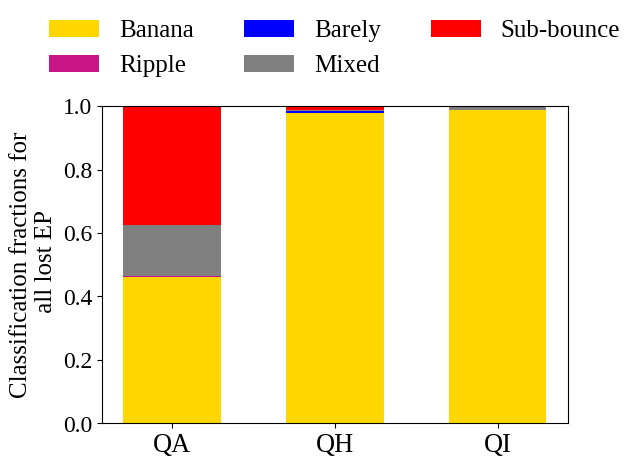

In [8]:
# A stacked bar chart showing the fraction of bounce segments spent as banana trapped, ripple trapped, and barely trapped

# NOTE THIS WORKFLOW IS NOT TAKING BARELY TRAPPED PARTICLES OUT OF THE SUB-BOUNCE CATEGORY WHICH THEORETICALLY WOULD NEED TO BE DONE, BUT THIS IS NOT AN ISSUE IN THIS DATA
# I BELIEVE THE ASSERT STATEMENTS WOULD FAIL IF THIS IS AN ISSUE

QA_banana_frac = QA_banana / QA_total
QA_ripple_frac = QA_ripple / QA_total
QA_barely_frac = QA_barely / QA_total
QA_mixed_frac = QA_mixed / QA_total
QA_prompt_frac = QA_prompt / QA_total

QH_banana_frac = QH_banana / QH_total
QH_ripple_frac = QH_ripple / QH_total
QH_barely_frac = QH_barely / QH_total
QH_mixed_frac = QH_mixed / QH_total
QH_prompt_frac = QH_prompt / QH_total

QI_banana_frac = QI_banana / QI_total
QI_ripple_frac = QI_ripple / QI_total
QI_barely_frac = QI_barely / QI_total
QI_mixed_frac = QI_mixed / QI_total
QI_prompt_frac = QI_prompt / QI_total


labels = ["QA", "QH", "QI"]
banana = np.array([QA_banana_frac, QH_banana_frac, QI_banana_frac])
ripple = np.array([QA_ripple_frac, QH_ripple_frac, QI_ripple_frac])
barely = np.array([QA_barely_frac, QH_barely_frac, QI_barely_frac])
mixed = np.array([QA_mixed_frac, QH_mixed_frac, QI_mixed_frac])
prompt = np.array([QA_prompt_frac, QH_prompt_frac, QI_prompt_frac])
x = np.arange(len(labels))
width = 0.6
fig, ax = plt.subplots()
ax.bar(x, banana, width, label="Banana",color="gold")
ax.bar(x, ripple, width, bottom=banana, label="Ripple",color="mediumvioletred")
ax.bar(x, barely, width, bottom=banana+ripple, label="Barely",color="blue")
ax.bar(x, mixed, width, bottom=banana+ripple+barely, label="Mixed",color="gray")
ax.bar(x, prompt, width, bottom=banana+ripple+barely+mixed, label="Sub-bounce",color="red")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=FontSize+1)
ax.set_ylabel("Classification fractions for\n all lost EP", fontsize=FontSize)
ax.set_ylim(0, 1)
ax.tick_params(axis="y", labelsize=FontSize-1)
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=False,
    fontsize=FontSize,
)
fig.tight_layout()

plt.savefig("figures/LossFractions_t1e-1.pdf")

plt.show()

Figures for Labbate et al., 2026

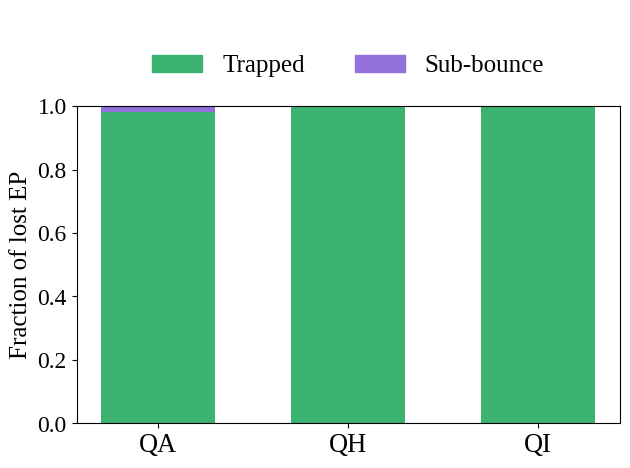

In [9]:
# A stacked bar chart of trapped fraction vs. passing fraction for QA,QH,QI with trapped fraction being 1 or more bounces (shows trapped particles are important)
font_size = 18
labels = ["QA", "QH", "QI"]
trapped = np.array([QA_trapped, QH_trapped, QI_trapped])
passing = np.array([QA_passing, QH_passing, QI_passing])
# fractions (optional)
totals = trapped + passing
trapped_frac = trapped / totals
passing_frac = passing / totals
x = np.arange(len(labels))
width = 0.6
fig, ax = plt.subplots()
ax.bar(x, trapped_frac, width, label="Trapped", color="mediumseagreen")
ax.bar(x, passing_frac, width, bottom=trapped_frac, label="Sub-bounce", color="mediumpurple")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=font_size+1)
ax.set_ylabel("Fraction of lost EP", fontsize=font_size)
ax.set_ylim(0, 1)
ax.tick_params(axis="y", labelsize=font_size-1)
# Match TrappedFractions: ncol=3, 2 rows (empty second row reserves legend height)
from matplotlib.patches import Patch

blank = Patch(facecolor="none", edgecolor="none")
legend_handles = [
    blank,
    Patch(facecolor="mediumseagreen", edgecolor="mediumseagreen", label="Trapped"),
    blank,
    Patch(facecolor="mediumpurple", edgecolor="mediumpurple", label="Sub-bounce"),
]
legend_labels = [ "","Trapped",  "", "Sub-bounce"]
ax.legend(
    legend_handles,
    legend_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=False,
    fontsize=font_size,
)
fig.tight_layout()
plt.savefig("figures/LossFractions.pdf")
plt.show()

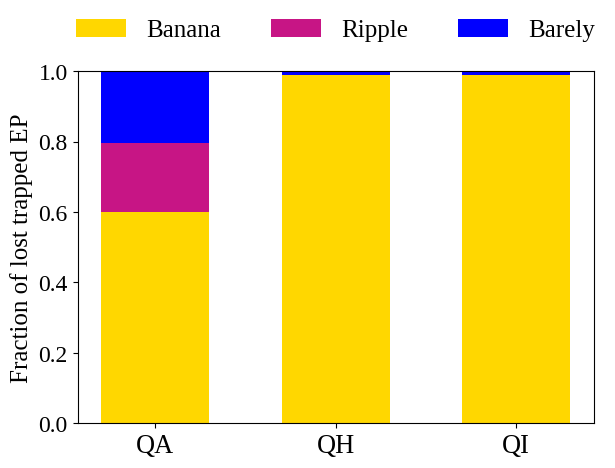

In [10]:
# A stacked bar chart showing the fraction of bounce segments spent as banana trapped, ripple trapped, and barely trapped (segments / total bounce segments considered, summed over all nbounce>1 particles) for QA,QH,QI (shows that banana trapped particles are most common)

QA_total_banana = QA_banana + QA_ripple_trapped + QA_barely_trapped
QA_banana_frac = QA_banana / QA_total_banana
QA_ripple_frac = QA_ripple_trapped / QA_total_banana
QA_barely_frac = QA_barely_trapped / QA_total_banana

QH_total_banana = QH_banana + QH_ripple_trapped + QH_barely_trapped
QH_banana_frac = QH_banana / QH_total_banana
QH_ripple_frac = QH_ripple_trapped / QH_total_banana
QH_barely_frac = QH_barely_trapped / QH_total_banana

QI_total_banana = QI_banana + QI_ripple_trapped + QI_barely_trapped
QI_banana_frac = QI_banana / QI_total_banana
QI_ripple_frac = QI_ripple_trapped / QI_total_banana
QI_barely_frac = QI_barely_trapped / QI_total_banana


labels = ["QA", "QH", "QI"]
banana = np.array([QA_banana_frac, QH_banana_frac, QI_banana_frac])
ripple = np.array([QA_ripple_frac, QH_ripple_frac, QI_ripple_frac])
barely = np.array([QA_barely_frac, QH_barely_frac, QI_barely_frac])
x = np.arange(len(labels))
width = 0.6
fig, ax = plt.subplots()
ax.bar(x, banana, width, label="Banana",color="gold")
ax.bar(x, ripple, width, bottom=banana, label="Ripple",color="mediumvioletred")
ax.bar(x, barely, width, bottom=banana+ripple, label="Barely",color="blue")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=font_size+1)
ax.set_ylabel("Fraction of lost trapped EP", fontsize=font_size)
ax.set_ylim(0, 1)
ax.tick_params(axis="y", labelsize=font_size-1)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False, fontsize=font_size)
fig.tight_layout()

plt.savefig("figures/TrappedFractions.pdf")

plt.show()

Segments

In [11]:
QA_barely_trapped_count = []
QA_ripple_trapped_count = []
QA_banana_count = []
QA_total_count = []
for iParticle in range(nParticles):
    try:
        # Load particle data (only saved if lost to wall)
        dict = np.load(f"outputs/QA_segments/particle_{iParticle}.npz")
    except FileNotFoundError:
        continue

    QA_barely_trapped_count.append(dict["barely_trapped_count"])
    QA_ripple_trapped_count.append(dict["ripple_trapped_count"])
    QA_banana_count.append(dict["banana_count"])
    QA_total_count.append(dict["total_count"])

QA_barely_trapped_count = np.array(QA_barely_trapped_count)
QA_ripple_trapped_count = np.array(QA_ripple_trapped_count)
QA_banana_count = np.array(QA_banana_count)
QA_total_count = np.array(QA_total_count)


In [12]:
QH_barely_trapped_count = []
QH_ripple_trapped_count = []
QH_banana_count = []
QH_total_count = []
for iParticle in range(nParticles):
    try:
        # Load particle data (only saved if lost to wall)
        dict = np.load(f"outputs/QH_segments/particle_{iParticle}.npz")
    except FileNotFoundError:
        continue

    QH_barely_trapped_count.append(dict["barely_trapped_count"])
    QH_ripple_trapped_count.append(dict["ripple_trapped_count"])
    QH_banana_count.append(dict["banana_count"])
    QH_total_count.append(dict["total_count"])

QH_barely_trapped_count = np.array(QH_barely_trapped_count)
QH_ripple_trapped_count = np.array(QH_ripple_trapped_count)
QH_banana_count = np.array(QH_banana_count)
QH_total_count = np.array(QH_total_count)


In [13]:
QI_barely_trapped_count = []
QI_ripple_trapped_count = []
QI_banana_count = []
QI_total_count = []
for iParticle in range(nParticles):
    try:
        # Load particle data (only saved if lost to wall)
        dict = np.load(f"outputs/QI_segments/particle_{iParticle}.npz")
    except FileNotFoundError:
        continue

    QI_barely_trapped_count.append(dict["barely_trapped_count"])
    QI_ripple_trapped_count.append(dict["ripple_trapped_count"])
    QI_banana_count.append(dict["banana_count"])
    QI_total_count.append(dict["total_count"])

QI_barely_trapped_count = np.array(QI_barely_trapped_count)
QI_ripple_trapped_count = np.array(QI_ripple_trapped_count)
QI_banana_count = np.array(QI_banana_count)
QI_total_count = np.array(QI_total_count)

In [14]:
QA_barely_trapped_count_sum = np.sum(QA_barely_trapped_count)
QA_ripple_trapped_count_sum = np.sum(QA_ripple_trapped_count)
QA_banana_count_sum = np.sum(QA_banana_count)
QA_total_count_sum = np.sum(QA_total_count)

QH_barely_trapped_count_sum = np.sum(QH_barely_trapped_count)
QH_ripple_trapped_count_sum = np.sum(QH_ripple_trapped_count)
QH_banana_count_sum = np.sum(QH_banana_count)
QH_total_count_sum = np.sum(QH_total_count)

QI_barely_trapped_count_sum = np.sum(QI_barely_trapped_count)
QI_ripple_trapped_count_sum = np.sum(QI_ripple_trapped_count)
QI_banana_count_sum = np.sum(QI_banana_count)
QI_total_count_sum = np.sum(QI_total_count)


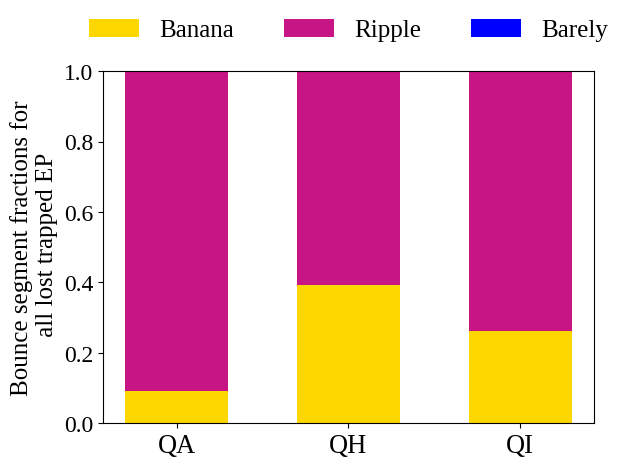

In [15]:
# A stacked bar chart showing the fraction of bounce segments spent as banana trapped, ripple trapped, and barely trapped

QA_banana_frac = QA_banana_count_sum / QA_total_count_sum
QA_ripple_frac = QA_ripple_trapped_count_sum / QA_total_count_sum
QA_barely_frac = QA_barely_trapped_count_sum / QA_total_count_sum

QH_banana_frac = QH_banana_count_sum / QH_total_count_sum
QH_ripple_frac = QH_ripple_trapped_count_sum / QH_total_count_sum
QH_barely_frac = QH_barely_trapped_count_sum / QH_total_count_sum

QI_banana_frac = QI_banana_count_sum / QI_total_count_sum
QI_ripple_frac = QI_ripple_trapped_count_sum / QI_total_count_sum
QI_barely_frac = QI_barely_trapped_count_sum / QI_total_count_sum


labels = ["QA", "QH", "QI"]
banana = np.array([QA_banana_frac, QH_banana_frac, QI_banana_frac])
ripple = np.array([QA_ripple_frac, QH_ripple_frac, QI_ripple_frac])
barely = np.array([QA_barely_frac, QH_barely_frac, QI_barely_frac])
x = np.arange(len(labels))
width = 0.6
fig, ax = plt.subplots()
ax.bar(x, banana, width, label="Banana",color="gold")
ax.bar(x, ripple, width, bottom=banana, label="Ripple",color="mediumvioletred")
ax.bar(x, barely, width, bottom=banana+ripple, label="Barely",color="blue")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=FontSize+1)
ax.set_ylabel("Bounce segment fractions for\n all lost trapped EP", fontsize=FontSize)
ax.set_ylim(0, 1)
ax.tick_params(axis="y", labelsize=FontSize-1)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False, fontsize=FontSize)
fig.tight_layout()

# plt.savefig("figures/TrappedFractions.pdf")

plt.show()

Instead of all segments, plot fractions for only the last segment

In [16]:
QA_barely_trapped_count_last = []
QA_ripple_trapped_count_last = []
QA_banana_count_last = []
QA_total_count_last = []
for iParticle in range(nParticles):
    try:
        # Load particle data (only saved if lost to wall)
        dict = np.load(f"outputs/QA_segments/particle_{iParticle}.npz")
    except FileNotFoundError:
        continue

    QA_barely_trapped_count_last.append(dict["barely_trapped_count_last"])
    QA_ripple_trapped_count_last.append(dict["ripple_trapped_count_last"])
    QA_banana_count_last.append(dict["banana_count_last"])
    QA_total_count_last.append(dict["total_count_last"])

QA_barely_trapped_count_last = np.array(QA_barely_trapped_count_last)
QA_ripple_trapped_count_last = np.array(QA_ripple_trapped_count_last)
QA_banana_count_last = np.array(QA_banana_count_last)
QA_total_count_last = np.array(QA_total_count_last)

QA_barely_trapped_count_sum_last = np.sum(QA_barely_trapped_count_last)
QA_ripple_trapped_count_sum_last = np.sum(QA_ripple_trapped_count_last)
QA_banana_count_sum_last = np.sum(QA_banana_count_last)
QA_total_count_sum_last = np.sum(QA_total_count_last)


In [17]:
QA_banana_frac_last = QA_banana_count_sum_last / QA_total_count_sum_last
QA_ripple_frac_last = QA_ripple_trapped_count_sum_last / QA_total_count_sum_last
QA_barely_frac_last = QA_barely_trapped_count_sum_last / QA_total_count_sum_last

In [18]:
QH_barely_trapped_count_last = []
QH_ripple_trapped_count_last = []
QH_banana_count_last = []
QH_total_count_last = []
for iParticle in range(nParticles):
    try:
        # Load particle data (only saved if lost to wall)
        dict = np.load(f"outputs/QH_segments/particle_{iParticle}.npz")
    except FileNotFoundError:
        continue

    QH_barely_trapped_count_last.append(dict["barely_trapped_count_last"])
    QH_ripple_trapped_count_last.append(dict["ripple_trapped_count_last"])
    QH_banana_count_last.append(dict["banana_count_last"])
    QH_total_count_last.append(dict["total_count_last"])

QH_barely_trapped_count_last = np.array(QH_barely_trapped_count_last)
QH_ripple_trapped_count_last = np.array(QH_ripple_trapped_count_last)
QH_banana_count_last = np.array(QH_banana_count_last)
QH_total_count_last = np.array(QH_total_count_last)

QH_barely_trapped_count_sum_last = np.sum(QH_barely_trapped_count_last)
QH_ripple_trapped_count_sum_last = np.sum(QH_ripple_trapped_count_last)
QH_banana_count_sum_last = np.sum(QH_banana_count_last)
QH_total_count_sum_last = np.sum(QH_total_count_last)


In [19]:
QH_banana_frac_last = QH_banana_count_sum_last / QH_total_count_sum_last
QH_ripple_frac_last = QH_ripple_trapped_count_sum_last / QH_total_count_sum_last
QH_barely_frac_last = QH_barely_trapped_count_sum_last / QH_total_count_sum_last

In [20]:
QI_barely_trapped_count_last = []
QI_ripple_trapped_count_last = []
QI_banana_count_last = []
QI_total_count_last = []
for iParticle in range(nParticles):
    try:
        # Load particle data (only saved if lost to wall)
        dict = np.load(f"outputs/QH_segments/particle_{iParticle}.npz")
    except FileNotFoundError:
        continue

    QI_barely_trapped_count_last.append(dict["barely_trapped_count_last"])
    QI_ripple_trapped_count_last.append(dict["ripple_trapped_count_last"])
    QI_banana_count_last.append(dict["banana_count_last"])
    QI_total_count_last.append(dict["total_count_last"])

QI_barely_trapped_count_last = np.array(QI_barely_trapped_count_last)
QI_ripple_trapped_count_last = np.array(QI_ripple_trapped_count_last)
QI_banana_count_last = np.array(QI_banana_count_last)
QI_total_count_last = np.array(QI_total_count_last)

QI_barely_trapped_count_sum_last = np.sum(QI_barely_trapped_count_last)
QI_ripple_trapped_count_sum_last = np.sum(QI_ripple_trapped_count_last)
QI_banana_count_sum_last = np.sum(QI_banana_count_last)
QI_total_count_sum_last = np.sum(QI_total_count_last)


In [21]:
# QI_noprompt = QI_barely_trapped_count_sum_last + QI_ripple_trapped_count_sum_last + QI_banana_count_sum_last
QI_prompt = QI_total_count_sum_last - (QI_barely_trapped_count_sum_last + QI_ripple_trapped_count_sum_last + QI_banana_count_sum_last)
QI_banana_frac_last = QI_banana_count_sum_last / QI_total_count_sum_last
QI_ripple_frac_last = QI_ripple_trapped_count_sum_last / QI_total_count_sum_last
QI_barely_frac_last = QI_barely_trapped_count_sum_last / QI_total_count_sum_last

In [22]:
# QH_noprompt = QH_barely_trapped_count_sum_last + QH_ripple_trapped_count_sum_last + QH_banana_count_sum_last
QH_prompt = QH_total_count_sum_last - (QH_barely_trapped_count_sum_last + QH_ripple_trapped_count_sum_last + QH_banana_count_sum_last)
QH_banana_frac_last = QH_banana_count_sum_last / QH_total_count_sum_last
QH_ripple_frac_last = QH_ripple_trapped_count_sum_last / QH_total_count_sum_last
QH_barely_frac_last = QH_barely_trapped_count_sum_last / QH_total_count_sum_last


In [23]:
# QA_noprompt = QA_barely_trapped_count_sum_last + QA_ripple_trapped_count_sum_last + QA_banana_count_sum_last
QA_prompt = QA_total_count_sum_last - (QA_barely_trapped_count_sum_last + QA_ripple_trapped_count_sum_last + QA_banana_count_sum_last)
QA_banana_frac_last = QA_banana_count_sum_last / QA_total_count_sum_last
QA_ripple_frac_last = QA_ripple_trapped_count_sum_last / QA_total_count_sum_last
QA_barely_frac_last = QA_barely_trapped_count_sum_last / QA_total_count_sum_last

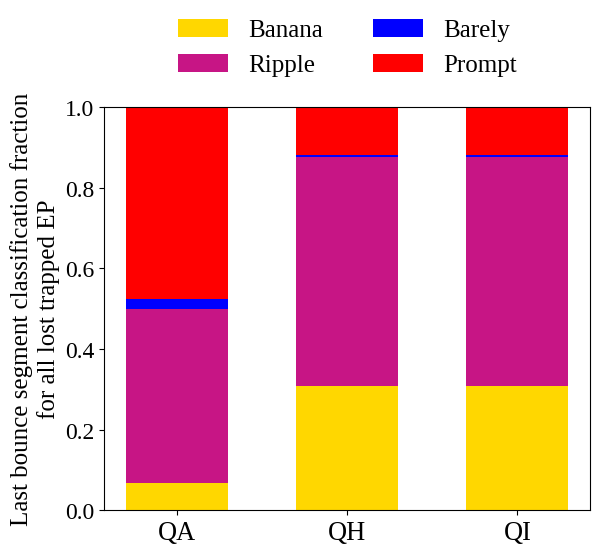

In [24]:
labels = ["QA", "QH", "QI"]
banana = np.array([QA_banana_frac_last, QH_banana_frac_last, QI_banana_frac_last])
ripple = np.array([QA_ripple_frac_last, QH_ripple_frac_last, QI_ripple_frac_last])
barely = np.array([QA_barely_frac_last, QH_barely_frac_last, QI_barely_frac_last])
prompt = np.array([QA_prompt, QH_prompt, QI_prompt])
x = np.arange(len(labels))
width = 0.6
fig, ax = plt.subplots()
ax.bar(x, banana, width, label="Banana",color="gold")
ax.bar(x, ripple, width, bottom=banana, label="Ripple",color="mediumvioletred")
ax.bar(x, barely, width, bottom=banana+ripple, label="Barely",color="blue")
ax.bar(x, prompt, width, bottom=banana+ripple+barely, label="Prompt",color="red")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=FontSize+1)
# ax.set_ylabel("Last bounce segment classification fraction for all lost trapped EP", fontsize=FontSize)
ax.set_ylabel(
    "Last bounce segment classification fraction\n"
    "for all lost trapped EP",
    fontsize=FontSize,
)
ax.set_ylim(0, 1)
ax.tick_params(axis="y", labelsize=FontSize-1)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False, fontsize=FontSize)
# fig.tight_layout()

plt.savefig("figures/TrappedFractions.pdf")

plt.show()